In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
def load_data(file_path):
    """Loads the cleaned dataset."""
    df = pd.read_csv(file_path)
    # ensuring data is sorted by date for time series analysis
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    return df

In [15]:
def prepare_data(df):
    """Selects features and target, and splits into train/test sets."""
    # X: features that influence the stock price
    # y: the stock price we want to predict
    features = ['Open', 'High', 'Low', 'Volume']
    target = 'Close'
    
    # using previous day's features to predict today's price
    X = df[features].shift(1).dropna()
    y = df[target]

    # Drop the first row because after shifting, row 0 will have NaN values
    X = X.dropna()
    y = y[X.index]  # make sure y aligns with X after dropping
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    return X_train, X_test, y_train, y_test

In [16]:
def train_linear_model(X_train, y_train):
    """Initializes and trains the Linear Regression model."""
    print("Training Linear Regression model...")
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [21]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Calculates accuracy metrics for both train and test sets."""
    train_predictions = model.predict(X_train)
    test_predictions  = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae  = mean_absolute_error(y_test,  test_predictions)
    # r2_score coefficient of determination as studied in probability
    train_r2  = r2_score(y_train, train_predictions)
    test_r2   = r2_score(y_test,  test_predictions)

    print("Model Evaluation:")
    print(f"Training's MAE: ${train_mae:.2f}  |  R²: {train_r2:.4f}")
    print(f"Testing's MAE: ${test_mae:.2f}  |  R²: {test_r2:.4f}")

    return train_predictions, test_predictions

In [22]:
def plot_prediction_results(y_train, train_preds, y_test, test_preds, n_points=100):
    """
    Side-by-side actual vs predicted plots for both train and test sets.
    n_points: how many points to display (first n from each split).
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Linear Regression: Actual vs Predicted Close Price', fontsize=15, fontweight='bold')

    # train set plot
    axes[0].plot(y_train.values[:n_points],    label='Actual',    color='steelblue',  lw=2,   marker='o', markersize=3)
    axes[0].plot(train_preds[:n_points],       label='Predicted', color='tomato',     lw=1.5, linestyle='--', marker='x', markersize=4)
    axes[0].set_title(f'Training Set (first {n_points} points)', fontsize=13)
    axes[0].set_xlabel('Data Points')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # test set plot
    axes[1].plot(y_test.values[:n_points],     label='Actual',    color='steelblue',  lw=2,   marker='o', markersize=3)
    axes[1].plot(test_preds[:n_points],        label='Predicted', color='tomato',     lw=1.5, linestyle='--', marker='x', markersize=4)
    axes[1].set_title(f'Test Set (first {n_points} points)', fontsize=13)
    axes[1].set_xlabel('Data Points')
    axes[1].set_ylabel('Price (USD)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

In [23]:
def run_ml_pipeline(file_path):
    """Orchestrates the machine learning workflow."""
    df = load_data(file_path)

    X_train, X_test, y_train, y_test = prepare_data(df)

    model = train_linear_model(X_train, y_train)

    train_predictions, test_predictions = evaluate_model(
        model, X_train, y_train, X_test, y_test
    )

    plot_prediction_results(y_train, train_predictions, y_test, test_predictions, n_points=1000)

    return model

Training Linear Regression model...
Model Evaluation:
Training's MAE: $45.35  |  R²: 0.0126
Testing's MAE: $90.24  |  R²: -0.1762


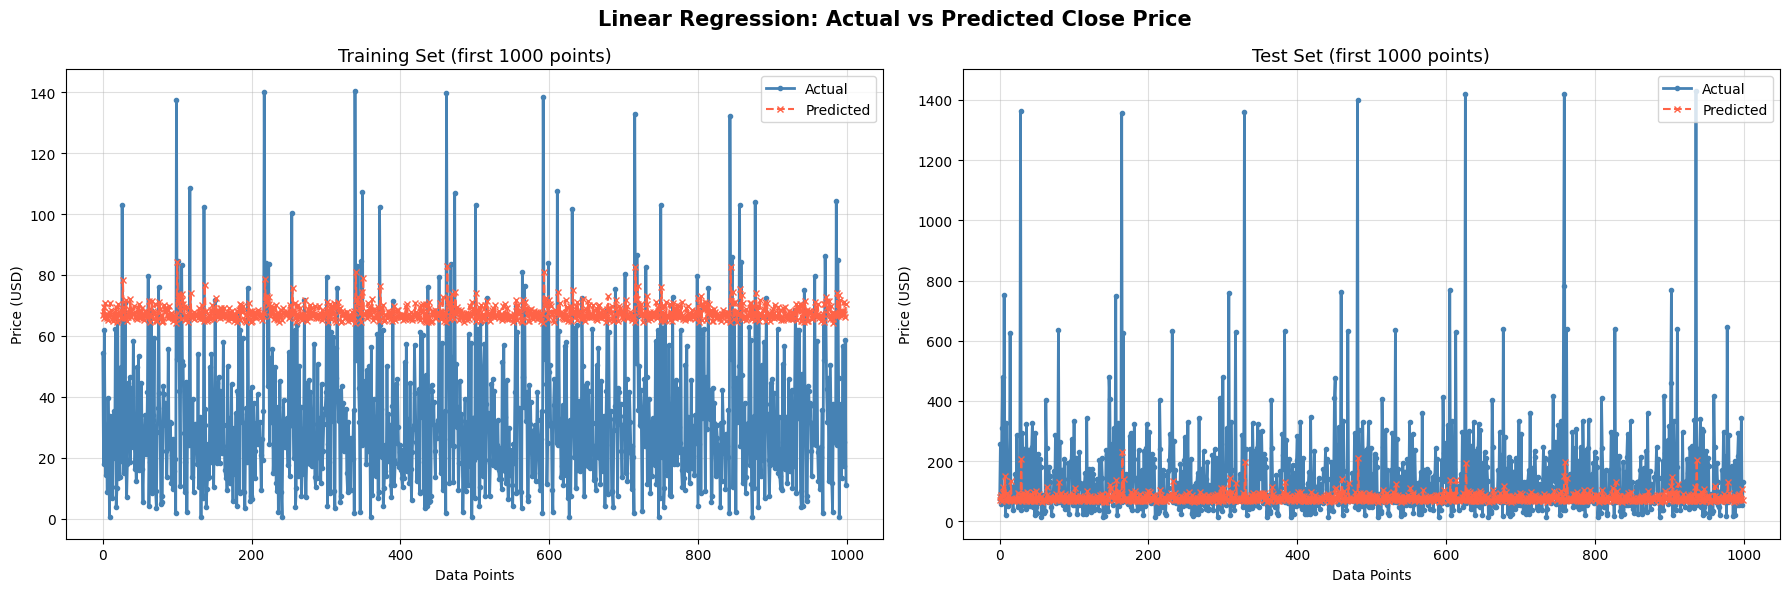

In [20]:
if __name__ == "__main__":
    trained_model = run_ml_pipeline('cleaned.csv')

In [1]:
# shuffle in prepare_data
# orchestrates in pipeline
# complete plot function